Accuracy: 0.956140350877193

Confusion Matrix:
 [[41  2]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



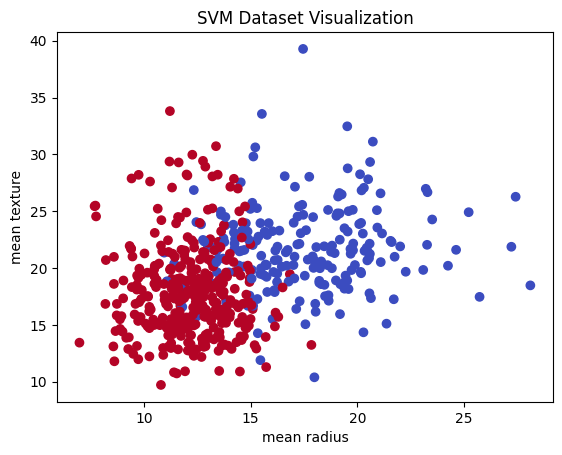

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset (available directly in sklearn)
data = load_breast_cancer()

X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create SVM model
model = SVC(kernel='linear')   # kernels: linear, rbf, poly, sigmoid

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---- Visualization using 2 features ----
# Using only first two features for plotting
X_vis = X[:, :2]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_v = scaler.fit_transform(X_train_v)
X_test_v = scaler.transform(X_test_v)

model_vis = SVC(kernel='linear')
model_vis.fit(X_train_v, y_train_v)

# Plot decision boundary
plt.scatter(X_vis[:,0], X_vis[:,1], c=y, cmap='coolwarm')
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("SVM Dataset Visualization")
plt.show()